---
##  Getting the Data 

### Downloading historical stock data with Yahoo Finance

**Why Yahoo Finance / `yfinance`?**
- It's free, doesn't need an API key, and gives clean daily OHLCV data going back many years.
- It covers Indian tickers too — NSE-listed stocks use the suffix `.NS` (e.g. `RELIANCE.NS`), and indices like NIFTY 50 are available as `^NSEI`, BANK NIFTY as `^NSEBANK`.

**Why start with the NIFTY 50 index instead of a single stock?**
An index is an *average* of many large companies, so it's less noisy and gives a cleaner first look at "overall market behavior" — which is exactly what microstructure analysis cares about. Later, you can swap in individual stocks (e.g. `RELIANCE.NS`, `TCS.NS`) using the same code.

> **Note:** This cell needs an active internet connection to reach Yahoo Finance's servers. Run it in your own Jupyter Notebook / Google Colab environment. If `yfinance` isn't installed, uncomment the pip install line below.


In [3]:
!pip install yfinance   

import yfinance as yf
import pandas as pd


TICKER = "^NSEI"         
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"

# auto_adjust=False keeps BOTH "Close" and a separate "Adj Close" column.
# (Newer yfinance versions default to auto_adjust=True, which silently REMOVES
# "Adj Close" and pre-adjusts "Close" instead -- we want to see and use both explicitly.)
df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False)

# Recent yfinance versions return MultiIndex columns like ('Close', '^NSEI') even for
# a single ticker. If we don't flatten this before saving to CSV, reading the CSV back
# later misreads the extra header row as a data row -- corrupting every column to
# "object" dtype. Flattening now avoids that problem completely.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)


df.to_csv("nifty50_data.csv")

print(f"Downloaded {df.shape[0]} rows and {df.shape[1]} columns for {TICKER}")
print("Columns:", list(df.columns))
df.head()



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\aditi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed

Downloaded 2459 rows and 6 columns for ^NSEI
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


**What just happened, line by line:**
- `import yfinance as yf` → loads the library that talks to Yahoo Finance's servers.
- `TICKER = "^NSEI"` → we store the symbol in a variable instead of hardcoding it everywhere. This is good practice: if you want to analyze a different stock later, you change **one line**, not every line of code.
- `yf.download(..., auto_adjust=False)` → sends a request to Yahoo Finance and returns a Pandas DataFrame (a table) of daily prices between our chosen dates. We explicitly set `auto_adjust=False` because newer versions of `yfinance` default to `auto_adjust=True`, which silently drops the separate `Adj Close` column (it pre-adjusts `Close` instead). We want both columns visible and explicit, since Step 4 depends on `Adj Close` existing.
- The `if isinstance(df.columns, pd.MultiIndex): ...` block → newer `yfinance` versions return **two-level column names** (e.g. `("Close", "^NSEI")`) even when you only ask for one ticker. If we don't flatten this to a normal single-level column name *before* saving to CSV, reading the file back later gets confused by the extra header row and turns every column into text (`object` dtype) instead of numbers. Flattening now prevents that entirely.
- `df.to_csv(...)` → saves the data to your computer. This means if Yahoo Finance is slow or down later, you can just reload this CSV instead of re-downloading.
- `df.head()` → shows the first 5 rows so we can sanity-check the data looks right.

> 💡 **If you already downloaded data before this fix and are seeing all your columns show up as `object` dtype with a `KeyError` on `Adj Close`:** just re-run the fixed download cell above to overwrite `nifty50_data.csv` with a clean version, then re-run Step 5's loading cell.

###  Understanding every column

When you run the cell above, the DataFrame will have these columns. Here's what each one means, in plain language:

| Column | Meaning | Beginner analogy |
|---|---|---|
| **Date** | The trading day this row represents | Like a diary entry — one entry per market day (weekends & holidays are skipped, since markets are closed) |
| **Open** | The price at which the very first trade of the day happened | The price "haggling" started at, when the market opened at 9:15 AM IST |
| **High** | The highest price reached at any point during the day | The most anyone was willing to pay that day |
| **Low** | The lowest price reached at any point during the day | The lowest anyone was willing to sell for that day |
| **Close** | The price at which the last trade of the day happened | The final agreed price when the market closed at 3:30 PM IST |
| **Adj Close** | The closing price, *adjusted* for things like dividends and stock splits | Makes prices comparable across time — e.g., if a stock splits 2-for-1, the raw price halves overnight, but Adj Close corrects for that so your returns calculation isn't thrown off |
| **Volume** | The total number of shares traded that day | How "busy" the market was for that stock/index that day — a proxy for liquidity |

**Why "Adj Close" matters so much in microstructure/return analysis:**
If a company pays a dividend or does a stock split, the *raw* Close price can jump or drop for reasons that have nothing to do with market sentiment. If we calculated daily returns using raw Close, we'd see a fake "crash" on split days. Adj Close removes this distortion — which is why we'll use **Adj Close** (not Close) whenever we calculate returns later.


1. **Using `Close` instead of `Adj Close` for return calculations** — leads to fake spikes/crashes around split or dividend dates.
2. **Forgetting that markets are closed on weekends/holidays** — beginners sometimes "fill" missing dates incorrectly, assuming data is missing/corrupted when really the market just didn't trade that day.
3. **Not saving a local CSV** — re-downloading from Yahoo Finance every time you rerun the notebook is slow and can fail if you lose internet access mid-project.


---
## Loading the Data & Inspecting It 

### Loading the dataset

Now that we've downloaded and saved our data, we load it back from the CSV file. **Why load from CSV instead of downloading fresh every time?**
- It's much faster.
- It keeps your analysis **reproducible** — everyone on your team analyzes the exact same snapshot of data, even if Yahoo Finance's numbers get revised later.
- It works even without internet access.


In [4]:
import pandas as pd
df = pd.read_csv("nifty50_data.csv", index_col=0, parse_dates=True)
df.index.name = "Date"
df.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


**Code Explaination Line by line:**
- `pd.read_csv(...)` → reads the CSV file back into a DataFrame.
- `index_col=0` → tells Pandas that the first column (our dates) should become the DataFrame's index, not a regular column. This makes time-based operations (like plotting a time series or resampling by month) much easier later.
- `parse_dates=True` → converts that index from plain text (e.g. `"2015-01-02"`) into an actual `datetime` type, so Pandas understands it as a real date and not just a string.
- `df.index.name = "Date"` → just a cosmetic touch so our index column is clearly labeled when we print things.

###  Data Inspection

Before touching or cleaning anything, we always **inspect** the data first. This is a non-negotiable habit in data science — you should never clean or analyze a dataset you haven't looked at carefully.


In [5]:
# Shape: Checks how many rows (days) and columns (features) we have.
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (2459, 6)


 `df.info()` matters: It's the single most useful "first look" command in Pandas. It tells you three things simultaneously:
- **Column names** — confirms Open/High/Low/Close/Adj Close/Volume are all present and spelled correctly.
- **Non-Null Count** — if a column shows fewer non-null values than total rows, you have missing data (more on this below).
- **Dtype** — confirms numeric columns are actually stored as numbers (`float64`), not accidentally as text (`object`). This is a very common beginner trap explained further down.


In [6]:
# 2. Info: column names, non-null counts, and data types all at once
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2459 entries, 2015-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2459 non-null   float64
 1   Close      2459 non-null   float64
 2   High       2459 non-null   float64
 3   Low        2459 non-null   float64
 4   Open       2459 non-null   float64
 5   Volume     2459 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 134.5 KB


In [7]:
# 3. Describe: statistical summary of all numeric columns
df.describe()


,Adj Close,Close,High,Low,Open,Volume
count,2459.000000,2459.000000,2459.000000,2459.000000,2459.000000,2.459000e+03
mean,13506.704131,13506.704131,13578.560372,13431.631915,13516.667489,3.223233e+05
std,4967.729528,4967.729528,4986.944771,4946.175825,4968.505490,1.949277e+05
min,6970.600098,6970.600098,7034.200195,6825.799805,7023.649902,0.000000e+00
25%,9347.000000,9347.000000,9423.325195,9299.875000,9375.750000,1.943000e+05
50%,11515.200195,11515.200195,11573.000000,11451.250000,11531.599609,2.624000e+05
75%,17531.450195,17531.450195,17622.575195,17422.250000,17530.674805,3.843000e+05
max,26216.050781,26216.050781,26277.349609,26151.400391,26248.250000,1.811000e+06


**How to read `df.describe()`:**
- **count** → how many non-missing values exist per column (should roughly match your row count).
- **mean / std** → the average price/volume and how spread out (volatile) it is.
- **min / max** → sanity-check for impossible values — e.g. a negative price or negative volume would indicate a data error.
- **25% / 50% / 75%** (quartiles) → gives a feel for the typical range without being thrown off by a few extreme outlier days.

This is also a great moment to catch data errors: if `min` for `Volume` is `0` or negative, or `High` is somehow *lower* than `Low` on some day, that's a red flag we'll deal with in (Data Cleaning).


In [8]:
# Missing values: Checkhow many empty cells does each column have.
df.isnull().sum()


Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

**Why missing values happen in stock data:**
- Yahoo Finance can occasionally have small gaps for specific dates (server issues, corporate actions, etc.).
- They are usually rare in daily index data, but it's still essential to check — a model or plot built on top of unexpected `NaN` values can silently produce wrong results (e.g. a moving average calculation skipping days without warning you).


In [9]:
#  Duplicate rows: are there any exact repeated rows?
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


**Why duplicates matter:** A duplicated row means the same trading day's data appears twice. If left in, it can silently bias your statistics (e.g. a volatile day would be "double-counted" in averages and standard deviations) and mess up time-series plots (two points for one date).


1. **Skipping inspection and jumping straight to plots/models.** Always run shape → info → describe → missing values → duplicates, in that order, before doing anything else.
2. **Ignoring the dtype of numeric columns.** If `Close` shows up as `object` instead of `float64`, Pandas is treating your prices as text — any math on that column will either crash or silently misbehave. This is very often caused by the `yfinance` MultiIndex column issue described in Step 3 — if you see this, re-check that your download cell flattened `df.columns` before saving to CSV.
3. **Assuming "no missing values shown = perfectly clean data."** `isnull().sum()` only catches *empty* cells — it won't catch things like a `High` price that's impossibly lower than `Low`, which is a logical error rather than a missing value. We'll specifically check for these logical errors in the next milestone (Data Cleaning).


---
##  Data Cleaning

 Cleaning always follows inspection — never the other way around, because you need to know what problems exist before deciding how to fix them.

cleaning order: **duplicates → missing values → logical errors → data types → sorting.**

### 1. Removing duplicate rows

 Now we drop them.


In [10]:
# Remove fully duplicated rows, keeping the first occurrence
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")


Removed 0 duplicate rows


**Why `keep the first occurrence`?** When a row is duplicated, both copies contain identical data, so it doesn't matter which one we keep — we just need exactly one. Keeping the first is the conventional default.

### 2. Handling missing values

For stock price data, there's an important rule: **never fill missing prices with the column mean or median.** Why? Because a stock price on a missing day is not "some average price" — it's most likely very close to the price on the day *right before or after* it. Using the overall mean would insert an unrealistic, disconnected value into a smooth time series and would distort any return/volatility calculation around that date.

The standard, sensible approach for time-series price data is **forward-fill**: carry the last known value forward until a new value appears.


In [11]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Forward-fill: carry the last valid price/volume forward
df = df.ffill()

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Missing values after cleaning:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


**Why forward-fill and not backward-fill?** Forward-fill only uses *past* information to fill a gap — which mirrors reality (on the day data was missing, the most recent known price *was* still the last traded price). Backward-fill would use *future* information, which doesn't reflect what was actually knowable at that point in time — this is a subtle form of "lookahead bias," a mistake that's especially dangerous in any finance project.

> If a `NaN` happens to be the very first row (no previous value to carry forward), forward-fill can't fix it. In that rare case, dropping that single row (`df.dropna()`) is the simplest safe option.

### Checking for logical errors

Missing values aren't the only kind of "bad" data. Stock data can have **logically impossible** rows that still contain numbers — for example, a day where `High` is somehow *lower* than `Open` or `Close`. By definition, `High` must be the maximum of the day and `Low` must be the minimum, so any violation of that is a data error, not a missing value, which is why `isnull()` alone couldn't catch it.


In [12]:
# A valid trading day must satisfy: Low <= Open, Close <= High
invalid_rows = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
]

print(f"Found {len(invalid_rows)} logically inconsistent rows")
invalid_rows


Found 0 logically inconsistent rows


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,


If this finds any rows, the safest beginner-friendly fix is usually to **drop them** (since fixing them would mean guessing the "correct" true price, which we can't know) — unless there are only a handful, in which case dropping a few rows out of thousands has negligible impact on the analysis:


In [13]:
df = df.drop(index=invalid_rows.index)
print("Shape after removing logically inconsistent rows:", df.shape)


Shape after removing logically inconsistent rows: (2459, 6)


###  Fixing data types

Even after cleaning values, it's worth double-checking every column has the *correct* type — numbers should be `float64`/`int64`, never `object` (text).


In [14]:
print(df.dtypes)

# If any price/volume column were accidentally stored as text, this converts it to numeric
# (errors="coerce" turns any unconvertible text into NaN, so we can catch it rather than crash)
for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop any new NaNs that may have appeared from forcing conversion (should normally be zero)
df = df.dropna()


Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object


###  Sorting by date

Time-series analysis (moving averages, returns, lag features — all coming up soon) assumes rows are in **chronological order**. It's easy to accidentally break this order after dropping/filtering rows, so we explicitly re-sort as a safety net.


In [15]:
df = df.sort_index()
print("Final cleaned shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
df.head()


Final cleaned shape: (2459, 6)
Date range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800



1. **Filling missing prices with `mean()` or `median()`.** This ignores the time-series nature of the data and can insert unrealistic values.
2. **Using backward-fill (`bfill`) without realizing it introduces lookahead bias** — using information that wasn't actually available at that point in time. This is one of the most serious mistakes in any finance/ML project because it can make your model look far more accurate than it really is.
3. **Only checking `isnull()` and assuming that's "cleaning done."** Logical errors (like High < Low) don't show up as missing values — you have to explicitly check business-logic rules for your specific data.
4. **Cleaning data in the wrong order** — e.g., sorting before removing duplicates can waste effort; always duplicates → missing values → logical checks → dtypes → sort, as we did above.


---
## Exploratory Data Analysis 

**Why EDA matters:** Before building any features or models, we need to *see* the data's shape and behavior with our own eyes. EDA helps us catch outliers, understand typical ranges, and form early hypotheses (e.g. "volatility looks higher after 2020") that we'll test more rigorously later.


- **Part 1 (this milestone):** Time Series Visualization + Univariate Analysis (distributions, boxplots)
- **Part 2 (next):** Bivariate Analysis, Correlation Heatmaps, Volume Analysis
- **Part 3 (after that):** Daily Return Analysis, Volatility Analysis, Moving Average Analysis




### Setting up our plotting libraries

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# A clean, readable default style for all our plots
sns.set_style("whitegrid")

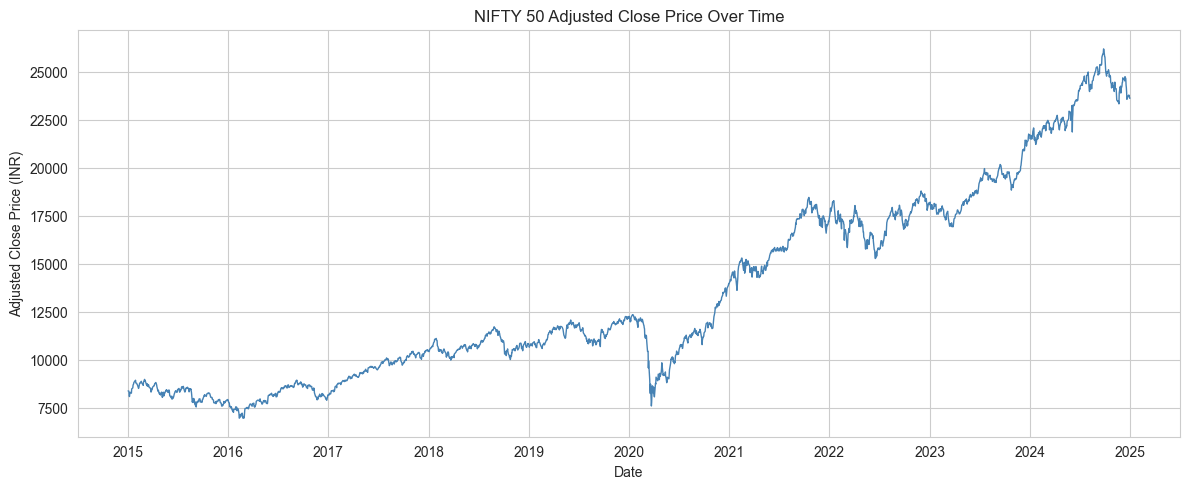

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Adj Close"], color="steelblue", linewidth=1)
plt.title("NIFTY 50 Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (INR)")
plt.tight_layout()
plt.show()


**How to interpret this chart:**
- An **overall upward slope** over many years reflects long-term market growth — expected for a broad index like NIFTY 50.
- **Sharp, sudden drops** (e.g., around early 2020) usually correspond to major shocks (like COVID-19) — worth noting as candidate "high volatility" periods we'll investigate quantitatively later.
- **Flatter, sideways stretches** suggest calmer, range-bound periods — a possible different "market regime."


### Univariate Analysis: Distribution Plots

**Why look at distributions?** A time series shows *when* things happened; a distribution plot shows *how often* different values occur, regardless of when. This helps answer: "Is the price data roughly symmetric, or skewed? Are there unusually extreme days?"


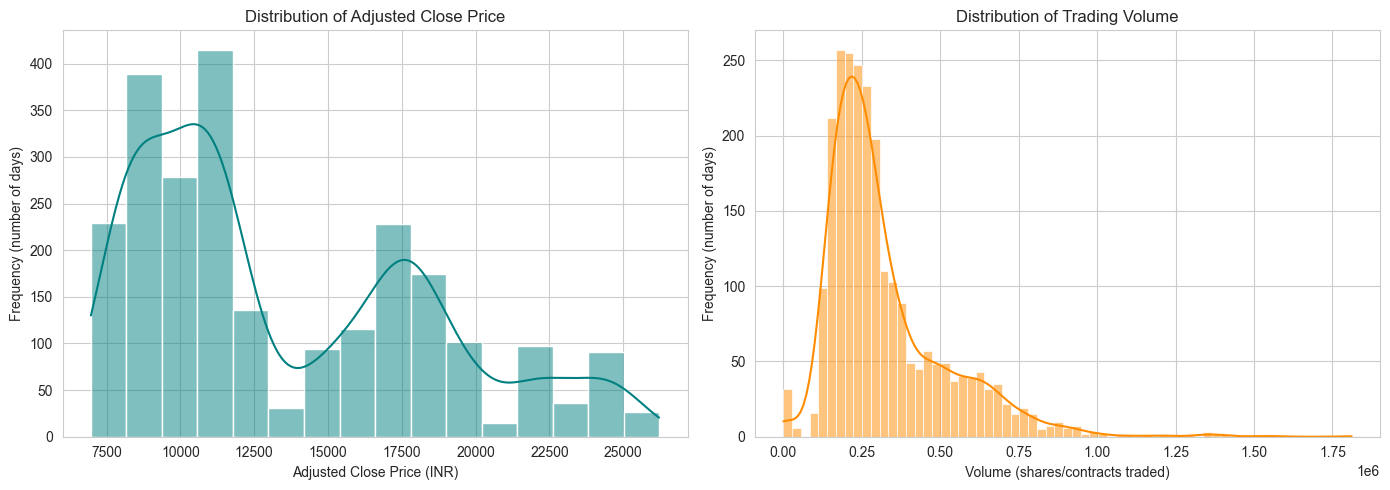

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Adj Close"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Adjusted Close Price")
axes[0].set_xlabel("Adjusted Close Price (INR)")
axes[0].set_ylabel("Frequency (number of days)")

sns.histplot(df["Volume"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Trading Volume")
axes[1].set_xlabel("Volume (shares/contracts traded)")
axes[1].set_ylabel("Frequency (number of days)")

plt.tight_layout()
plt.show()



- `sns.histplot(..., kde=True, ...)` → draws a histogram (bars showing how many days fall into each price/volume "bucket") plus a smooth KDE curve (Kernel Density Estimate) overlaid on top, which makes the overall shape easier to see than bars alone.
- We use `subplots(1, 2, ...)` to place Price and Volume side-by-side for easy comparison, since they're on very different scales and shouldn't share one axis.

**How to interpret these charts:**
- **Adjusted Close distribution:** For a long price history, this is often **not** a simple bell curve — it can be spread out or multi-peaked, because the index has traded at genuinely different price levels across different years (e.g., much lower a decade ago than recently). This is expected and different from a "bad" distribution.
- **Volume distribution:** Often **right-skewed** (a long tail toward high values) — most days have "typical" volume, but a handful of high-news-impact days have unusually large volume. This tail is exactly the kind of day we're interested in for microstructure analysis.

### Univariate Analysis: Boxplots

**Why boxplots in addition to histograms?** A boxplot is a compact summary that makes **outliers** immediately visible using a simple, standardized rule (points beyond 1.5× the interquartile range are flagged as outliers) — histograms show shape, but boxplots are better at flagging "how extreme are the extreme days?"


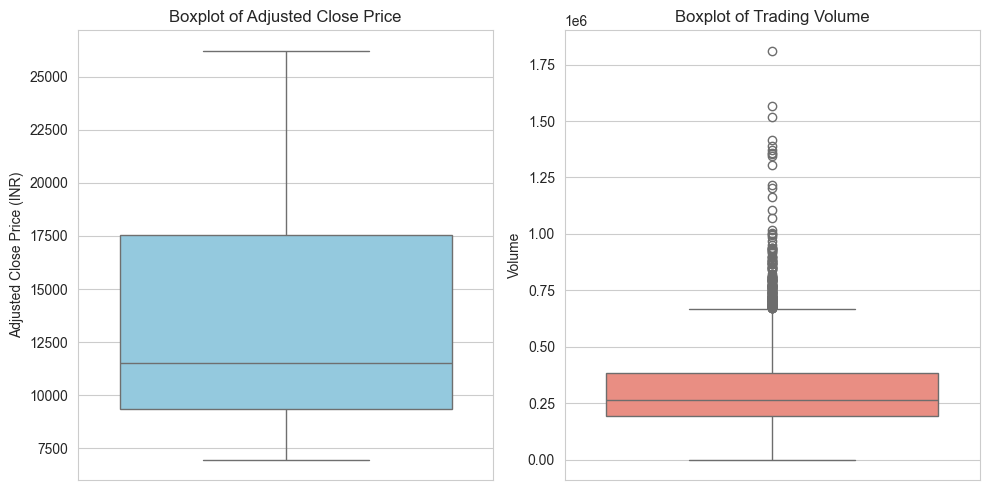

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=df["Adj Close"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot of Adjusted Close Price")
axes[0].set_ylabel("Adjusted Close Price (INR)")

sns.boxplot(y=df["Volume"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Trading Volume")
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()


**How to interpret a boxplot:**
- The **box** covers the middle 50% of days (25th to 75th percentile) — the "typical" range.
- The **line inside the box** is the median.
- The **whiskers** extend to the normal range of data.
- Individual **dots beyond the whiskers** are statistical outliers — for Volume, these are usually the high-activity days we flagged in the histogram; for Price, isolated outlier dots are less meaningful (price naturally drifts over a decade) — this is a good example of a chart needing *context* (in this case, the time series above) rather than being read in isolation.

